# 4.6 直流回路

- **4.6.1 抵抗の接続**
- 4.6.2 電池の起電力と内部抵抗
- 4.6.3 電流計と電圧計
- 4.6.4 キルヒホッフの法則

In [ ]:
#@title おまじない
! pip -qqq install schemdraw
#! pip show schemdraw
! pip -qqq install ziamath

%matplotlib inline
%config InlineBackend.figure_format = 'svg'
import schemdraw
import schemdraw.elements as elm

schemdraw.config(font='cmb10')
#elm.style(elm.STYLE_IEC) # IEC/European style
elm.style(elm.STYLE_IEEE) # IEEE style

#schemdraw.config(mathfont='cm')
#import matplotlib.pyplot as plt
#plt.xkcd()

## 物理量の数値と単位の抽出方法

- 電流 $I = 5~{\rm A}$ としたとき
  - 電流の数値を $\{I\}=5$
  - 電流の単位を $[I]={\rm A}$

- 電圧 $V = 100~{\rm V}$ としたとき
  - 電流の数値を $\{V\}=100$
  - 電流の単位を $[V]={\rm V}$

- 抵抗 $R = 80~{\rm \Omega}$ としたとき
  - 電流の数値を $\{R\}=80$
  - 電流の単位を $[R]={\rm \Omega}$  

で取り出すこととする。

---
ref.
https://www.jstage.jst.go.jp/article/peu/25/1/25_2/_article/-char/ja/

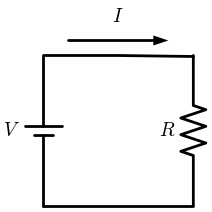

In [ ]:
#@title 基本還元回路

with schemdraw.Drawing(mathfont='cm') as d:
  elm.BatteryCell().down().label("$V$")
  elm.Line().right()
  elm.Resistor().up().label('$R$')
  L0=elm.Line().left()
  elm.CurrentLabel(top=False, ofst=.3, reverse=True).at(L0).label('$I$')

この小節で考えることは、
> 直列・並列・直並列の抵抗があっても、  
> 上記の **一つの回路に置き換えた** 場合の、**合成抵抗** $R$ を求める.

ことにある。直上の図では、
- 二本線で描かれたものは、 電池/Battery
  - マイナス(下流)からプラス(上流)に電流 $I$ を引き上げるために、  
  電圧 $V$ をもつ
- 四角い箱は、(欧州方式の) 抵抗 $R$
 - 高い電位 $V$ の状態(上流)から  
下の電位(この場合は $0~{\rm V}$, 下流)まで下げる  

- 定常電流が従う、オームの法則 $V=R\,I$ は成り立つものとする

---
電圧差 $V$ と電圧・電位の単位 ${\rm V}$ の違いに注意

## 4.6.1 抵抗の接続

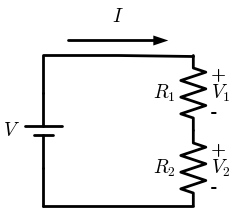

In [ ]:
#@title (1) 直列接続
with schemdraw.Drawing(mathfont='cm') as d:
#  d += elm.Line().down()
  elm.Line(l=d.unit/4).down()
  elm.BatteryCell(l=d.unit/2).down().label("$V$")
  elm.Line(l=d.unit/4).down()
  elm.Line().right()
  elm.Resistor(l=d.unit/2).up().label('$R_2$').label(['-','$V_2$','+'], loc='bot')
  elm.Resistor(l=d.unit/2).up().label('$R_1$').label(['-','$V_1$','+'], loc='bot')
  L1=elm.Line().left()
  elm.CurrentLabel(top=False, ofst=.3, reverse=True).at(L1).label('$I$')

直列抵抗を持つ回路図より、オームの法則に従って、整理すると
\begin{align*}
&V = V_1 + V_2\\
&\begin{cases}
V_1 &= R_1\,I\\
V_2 &= R_2\,I
\end{cases}.
\end{align*}

これを一つの回路 $V = R_{\rm srs}\,I$ で表すことを考える。

代入して整理すると
\begin{align*}
\require{cancel}
R_{\rm srs}\,\bcancel{I}
&= R_1\,\bcancel{I}
 + R_2\,\bcancel{I}\\[2mm]
R_{\rm srs} &= R_1 + R_2
\end{align*}

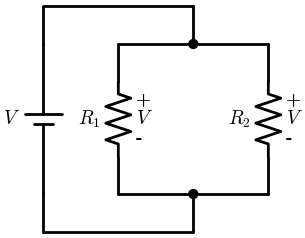

In [ ]:
#@title (2) 並列接続
with schemdraw.Drawing(mathfont='cm') as d:
  elm.Line(l=d.unit/4).down()
  elm.BatteryCell().down().label("$V$")
  elm.Line(l=d.unit/4).down()
  elm.Line().right()
  elm.Line(l=d.unit/4).up()
  elm.Dot()
  d.push()
  elm.Line(l=d.unit/2).left()
  elm.Line(l=d.unit/4).up()
  elm.Resistor(l=d.unit/2).up().label('$R_1$').label(['-','$V$','+'], loc='bot')
  elm.Line(l=d.unit/4).up()
  elm.Line(l=d.unit/2).right()
  d.pop()
  #push
  elm.Line(l=d.unit/2).right()
  elm.Line(l=d.unit/4).up()
  elm.Resistor(l=d.unit/2).up().label('$R_2$').label(['-','$V$','+'], loc='bot')
  elm.Line(l=d.unit/4).up()
  elm.Line(l=d.unit/2).left()
  #pop
  elm.Dot()
  elm.Line(l=d.unit/4).up()
  elm.Line().left()

並列抵抗を持つ回路図より、オームの法則に従って、整理すると
\begin{align*}
&\begin{cases}
V &= R_1\,I_1\\
V &= R_2\,I_2
\end{cases}\\
&I = I_1 + I_2
\end{align*}.

これを一つの回路 $V = R_{\rm prl}\,I$ で表すことを考える。

代入して整理すると
\begin{align*}
\require{cancel}
\dfrac{\bcancel{V}}{R_{\rm prl}}
&= \dfrac{\bcancel{V}}{R_1}
 + \dfrac{\bcancel{V}}{R_2}\\[2mm]
\dfrac{1}{R_{\rm prl}}
&= \dfrac{1}{R_1} + \dfrac{1}{R_2}\\[2mm]
R_{\rm prl}
&= \left(\dfrac{1}{R_1} + \dfrac{1}{R_2}\right)^{-1}
= \dfrac{R_1\,R_2}{R_1 + R_2}
\end{align*}

### 直並列接続

教科書の例題に挑戦してください。